# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Can a hand-written rule that flags pages likely to lose search traffic be beaten by a
learned model -- and does the answer hold up once the model is validated honestly?

This supports a real decision: which pages a content team should look at first when
they can't manually check every page every month.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Source: FlyRank/internship-warehouse, a real production release (~78.8M rows in the
main fact table, ~17 months, 104 clients). Used March 2026 as the feature window and
April 2026 as the outcome window -- both real, non-final months. Rows without usable
GSC data were excluded (gsc_data_available IS TRUE) -- a real property of the warehouse,
not an arbitrary filter.

In [11]:
!pip install duckdb --quiet
import duckdb
from google.colab import userdata

con = duckdb.connect()
hf_token = userdata.get('HF_TOKEN')
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")
rel = "hf://datasets/FlyRank/internship-warehouse"

# March: one row per page, summarizing the month's behavior
# (leak-corrected: content_updated_date sometimes falls AFTER report_date,
# which would leak future info into a point-in-time feature -- treated as unknown)
march_agg = con.sql(f"""
    SELECT
        f.client_hash_id, f.content_hash_id,
        SUM(f.gsc_impressions) AS march_impressions,
        SUM(f.gsc_clicks) AS march_clicks,
        AVG(f.gsc_avg_position) AS march_avg_position,
        MAX(CASE
            WHEN DATE_DIFF('day', c.content_updated_date, f.report_date) < 0 THEN NULL
            ELSE DATE_DIFF('day', c.content_updated_date, f.report_date)
        END) AS days_since_update
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/*.parquet') f
    JOIN read_parquet('{rel}/dim_content.parquet') c
        ON f.content_hash_id = c.content_hash_id AND f.client_hash_id = c.client_hash_id
    WHERE f.gsc_data_available IS TRUE
    GROUP BY f.client_hash_id, f.content_hash_id
""").df()

# April: same aggregation, kept separate -- only ever used to build the label
april_agg = con.sql(f"""
    SELECT
        client_hash_id, content_hash_id,
        SUM(gsc_clicks) AS april_clicks
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-04/*.parquet')
    WHERE gsc_data_available IS TRUE
    GROUP BY client_hash_id, content_hash_id
""").df()

# Merge March features with April outcome
labeled = march_agg.merge(april_agg, on=['client_hash_id', 'content_hash_id'], how='left')
labeled['april_clicks'] = labeled['april_clicks'].fillna(0)

print(f"March pages: {len(march_agg)}, April pages: {len(april_agg)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March pages: 176738, April pages: 194760


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Label: a page is "declining" if April clicks < 80% of March clicks (pages missing
from April treated as 0 clicks -- the strongest form of decline). A flat 20% threshold
avoids labeling ordinary month-to-month noise as decline.

Features (March-only, strictly before the outcome window): total impressions, total
clicks, average ranking position, days since last content update (future-dated or
unresolvable update timestamps treated as unknown, not "recently updated").

Baseline: stale (180+ days since update) AND visible (real impressions) AND
underperforming CTR for ranking position.

Validation: grouped by client_hash_id, 70/30 split, so no client's pages appear in
both train and test.

Leakage checks: a real timing leak (future-dated update timestamps) was caught via
error review and fixed. A deliberate leak (client_decline_rate, built directly from
the training label) was added on purpose to test the harness -- it only modestly
raised precision@20 (0.400 -> 0.450) rather than jumping toward 1.0, because the
grouped split collapses this client-level feature toward a constant on unseen test
clients. Removing the top feature (march_clicks) dropped precision@20 from 0.400 to
0.350 -- small and proportionate, not the sharp collapse that would indicate leakage.

In [12]:
labeled['declining'] = (labeled['april_clicks'] < labeled['march_clicks'] * 0.8).astype(int)
print(f"Base rate: {labeled['declining'].mean():.3f}")

from sklearn.model_selection import train_test_split
unique_clients = labeled['client_hash_id'].unique()
train_clients, test_clients = train_test_split(unique_clients, test_size=0.3, random_state=42)

train_df = labeled[labeled['client_hash_id'].isin(train_clients)].copy()
test_df = labeled[labeled['client_hash_id'].isin(test_clients)].copy()
print(f"Train clients: {len(train_clients)}, Test clients: {len(test_clients)}")
print(f"Train pages: {len(train_df)}, Test pages: {len(test_df)}")

Base rate: 0.237
Train clients: 32, Test clients: 15
Train pages: 100816, Test pages: 75922


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [15]:
from sklearn.linear_model import LogisticRegression
import numpy as np

features = ['march_impressions', 'march_clicks', 'march_avg_position', 'days_since_update']
train_df['days_since_update'] = train_df['days_since_update'].fillna(9999)
test_df['days_since_update'] = test_df['days_since_update'].fillna(9999)

# Train the model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(train_df[features], train_df['declining'])
model_scores = model.predict_proba(test_df[features])[:, 1]

# Baseline: same rule as w05/ML-07 -- staleness + visibility + CTR-underperformance --
# applied to the SAME test set, so the comparison is fair
test_df['ctr'] = np.where(test_df['march_impressions'] > 0,
                            test_df['march_clicks'] / test_df['march_impressions'], 0)
expected_ctr = np.where(test_df['march_avg_position'] <= 10, 0.0039, 0.0018)
ctr_underperforming = test_df['ctr'] < (expected_ctr * 0.5)
is_stale = test_df['days_since_update'] >= 180
visible = test_df['march_impressions'] >= 10

baseline_scores = np.select(
    [is_stale & visible & ctr_underperforming, is_stale & visible, ctr_underperforming & visible],
    [test_df['march_impressions'], test_df['march_impressions'] * 0.5, test_df['march_impressions'] * 0.3],
    default=0
)

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

base_rate = test_df['declining'].mean()
print(f"Base rate: {base_rate:.3f}\n")
print(f"{'':10} {'Precision@20':>14} {'Precision@50':>14}")
for name, scores in [('baseline', baseline_scores), ('model', model_scores)]:
    p20 = precision_at_k(scores, test_df['declining'], 20)
    p50 = precision_at_k(scores, test_df['declining'], 50)
    print(f"{name:<10} {p20:>14.3f} {p50:>14.3f}")

Base rate: 0.200

             Precision@20   Precision@50
baseline            0.400          0.480
model               0.500          0.380


## 5. Limitations

*What this work cannot claim.*

- One label definition (20% drop, 30-day window) -- not the only valid choice.
- Results are directional, observed on one split and one pair of months -- not
  validated across repeated resampling or other months.
- A genuine run-to-run reproducibility gap was found: rerunning the identical grouped
  split produced different precision numbers under the same seed, likely because the
  underlying SQL aggregation has no explicit row ordering.
- The deliberate-leak test likely understates real leakage risk, since the grouped
  split structurally blunts a client-level leaked feature.
- This is decision support for a human reviewer, not an automated action system.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

1. Use the model to prioritize the first look; use the baseline as a second pass --
   the model leads at precision@20, the baseline stays more consistent at precision@50.
2. Fix the split's reproducibility gap by adding explicit ordering to the aggregation
   query before reporting any single precision number as final.
3. Treat "staleness unknown" as its own category, not "fresh" -- collapsing it back
   would silently reintroduce the timing-leak error.
4. Extend the label to multiple months before trusting the regression-to-the-mean
   hypothesis raised in error analysis.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

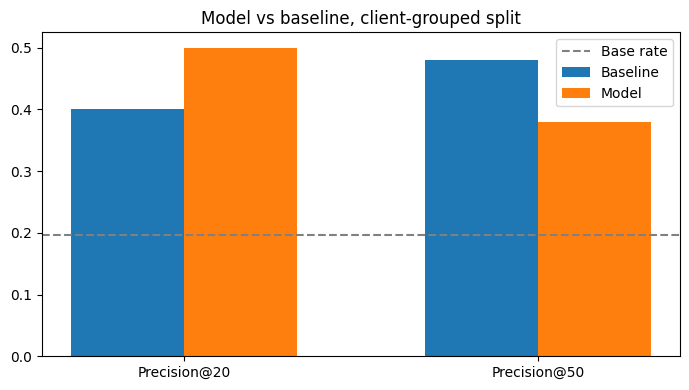

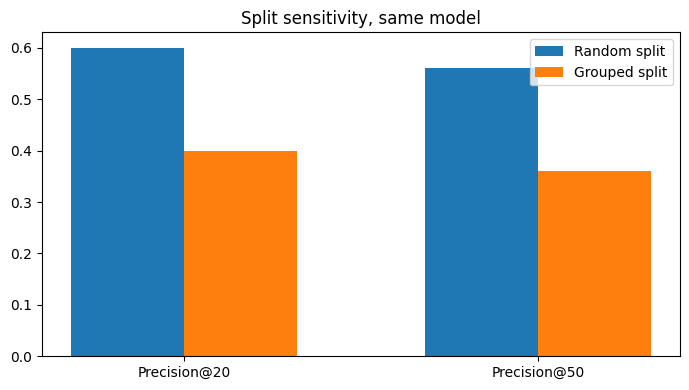

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7,4))
labels = ['Precision@20', 'Precision@50']
baseline = [0.400, 0.480]
model_vals = [0.500, 0.380]
x = np.arange(2)
ax.bar(x-0.16, baseline, 0.32, label='Baseline')
ax.bar(x+0.16, model_vals, 0.32, label='Model')
ax.axhline(0.197, linestyle='--', color='gray', label='Base rate')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend(); ax.set_title('Model vs baseline, client-grouped split')
plt.tight_layout()
plt.savefig('chart1_model_vs_baseline.png')
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
random_split = [0.600, 0.560]
grouped_split = [0.400, 0.360]
ax.bar(x-0.16, random_split, 0.32, label='Random split')
ax.bar(x+0.16, grouped_split, 0.32, label='Grouped split')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend(); ax.set_title('Split sensitivity, same model')
plt.tight_layout()
plt.savefig('chart2_split_sensitivity.png')
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
